# CBSA Graph Histograms by Year

Loads all `*_connected.json` graphs from `cbsas/{year}/` for years 1980–2020 and plots histograms of:
- **Number of nodes** per CBSA
- **Number of edges** per CBSA
- **Total population** per CBSA (sum of `TOTPOP` across all tracts)
- **Degree distribution** (all node degrees flattened across all CBSAs)

Set `SAMPLE_SIZE` to `None` to load every file (~2300/year); default is 500 for speed.

In [1]:
import json
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

YEARS                  = [1980, 1990, 2000, 2010, 2020]
CBSA_DIR               = 'study_areas'
CENSUS_GEOGRAPHY_TYPE  = 'tracts'   # 'tracts' or 'block_groups'
SAMPLE_SIZE            = 500        # set to None to load all files per year
VINTAGE                = 'march_2020'

In [2]:
import pandas as pd

df = pd.read_csv("cbsas.csv")

cbsa_dict = dict(zip(df["CBSA Code"], df["CBSA Name"]))

In [3]:
def load_year(year, vintage=None, sample_size=None, cbsa_names=None):
    """Return list of per-CBSA summary dicts for a given census year."""
    pattern = os.path.join(CBSA_DIR, str(year), f'{CENSUS_GEOGRAPHY_TYPE}_in_cbsa_*_{year}_*_vintage_connected.json')
    files = sorted(glob.glob(pattern))
    if vintage is not None:
        files = [f for f in files if vintage in os.path.basename(f)]
    if sample_size is not None:
        files = files[:sample_size]

    records = []
    for fp in files:
        try:
            with open(fp) as f:
                d = json.load(f)
            nodes = d['nodes']
            adj = d['adjacency']
            n_nodes = len(nodes)
            # adjacency is undirected: each edge appears twice
            n_edges = sum(len(a) for a in adj) // 2
            total_pop = sum((n.get('TOTPOP') or 0) for n in nodes)
            degrees = [len(a) for a in adj]
            n_leaves = sum(1 for deg in degrees if deg == 1)
            fname = os.path.basename(fp)
            parts = fname.split('_')
            # filename: {geo_type}_in_cbsa_{code}_{year}_...
            code = int(parts[3]) if len(parts) > 3 else None
            name = cbsa_names.get(code, '') if cbsa_names and code is not None else ''
            records.append({
                'file': fname,
                'cbsa_code': code,
                'cbsa_name': name,
                'n_nodes': n_nodes,
                'n_edges': n_edges,
                'n_leaves': n_leaves,
                'total_pop': total_pop,
                'degrees': degrees,
            })
        except Exception as e:
            print(f'  skipped {os.path.basename(fp)}: {e}')
            continue
    return records


data = {}
for yr in YEARS:
    print(f'Loading {yr}...', end=' ', flush=True)
    data[yr] = load_year(yr, vintage=VINTAGE, sample_size=SAMPLE_SIZE, cbsa_names=cbsa_dict)
    print(f'{len(data[yr])} graphs')

Loading 1980... 335 graphs
Loading 1990... 384 graphs
Loading 2000... 392 graphs
Loading 2010... 392 graphs
Loading 2020... 392 graphs


In [4]:
# ── Tukey upper-fence thresholds (pooled across all decades) ──────────────────
def tukey_upper(vals):
    q1, q3 = np.percentile(vals, [25, 75])
    return q3 + 1.5 * (q3 - q1)

thresh_nodes  = tukey_upper([r['n_nodes']   for yr in YEARS for r in data[yr]])
thresh_edges  = tukey_upper([r['n_edges']   for yr in YEARS for r in data[yr]])
thresh_pop    = tukey_upper([r['total_pop'] for yr in YEARS for r in data[yr]])
thresh_deg    = tukey_upper([d              for yr in YEARS for r in data[yr] for d in r['degrees']])
thresh_leaves = tukey_upper([r['n_leaves']  for yr in YEARS for r in data[yr]])

lines = [
    f"Tukey upper-fence thresholds (pooled across {YEARS}, vintage={VINTAGE}):",
    f"  Nodes:      {thresh_nodes:>12,.0f}",
    f"  Edges:      {thresh_edges:>12,.0f}",
    f"  Population: {thresh_pop:>12,.0f}",
    f"  Degree:     {thresh_deg:>12.1f}",
    f"  Leaves:     {thresh_leaves:>12,.0f}",
]
for line in lines:
    print(line)

os.makedirs('figures', exist_ok=True)
with open('figures/thresholds.txt', 'w') as f:
    f.write('\n'.join(lines) + '\n')
print('Saved figures/thresholds.txt')

Tukey upper-fence thresholds (pooled across [1980, 1990, 2000, 2010, 2020], vintage=march_2020):
  Nodes:               239
  Edges:               637
  Population:    1,033,649
  Degree:              9.0
  Leaves:                2
Saved figures/thresholds.txt


Saved figures/cbsa_histograms.png


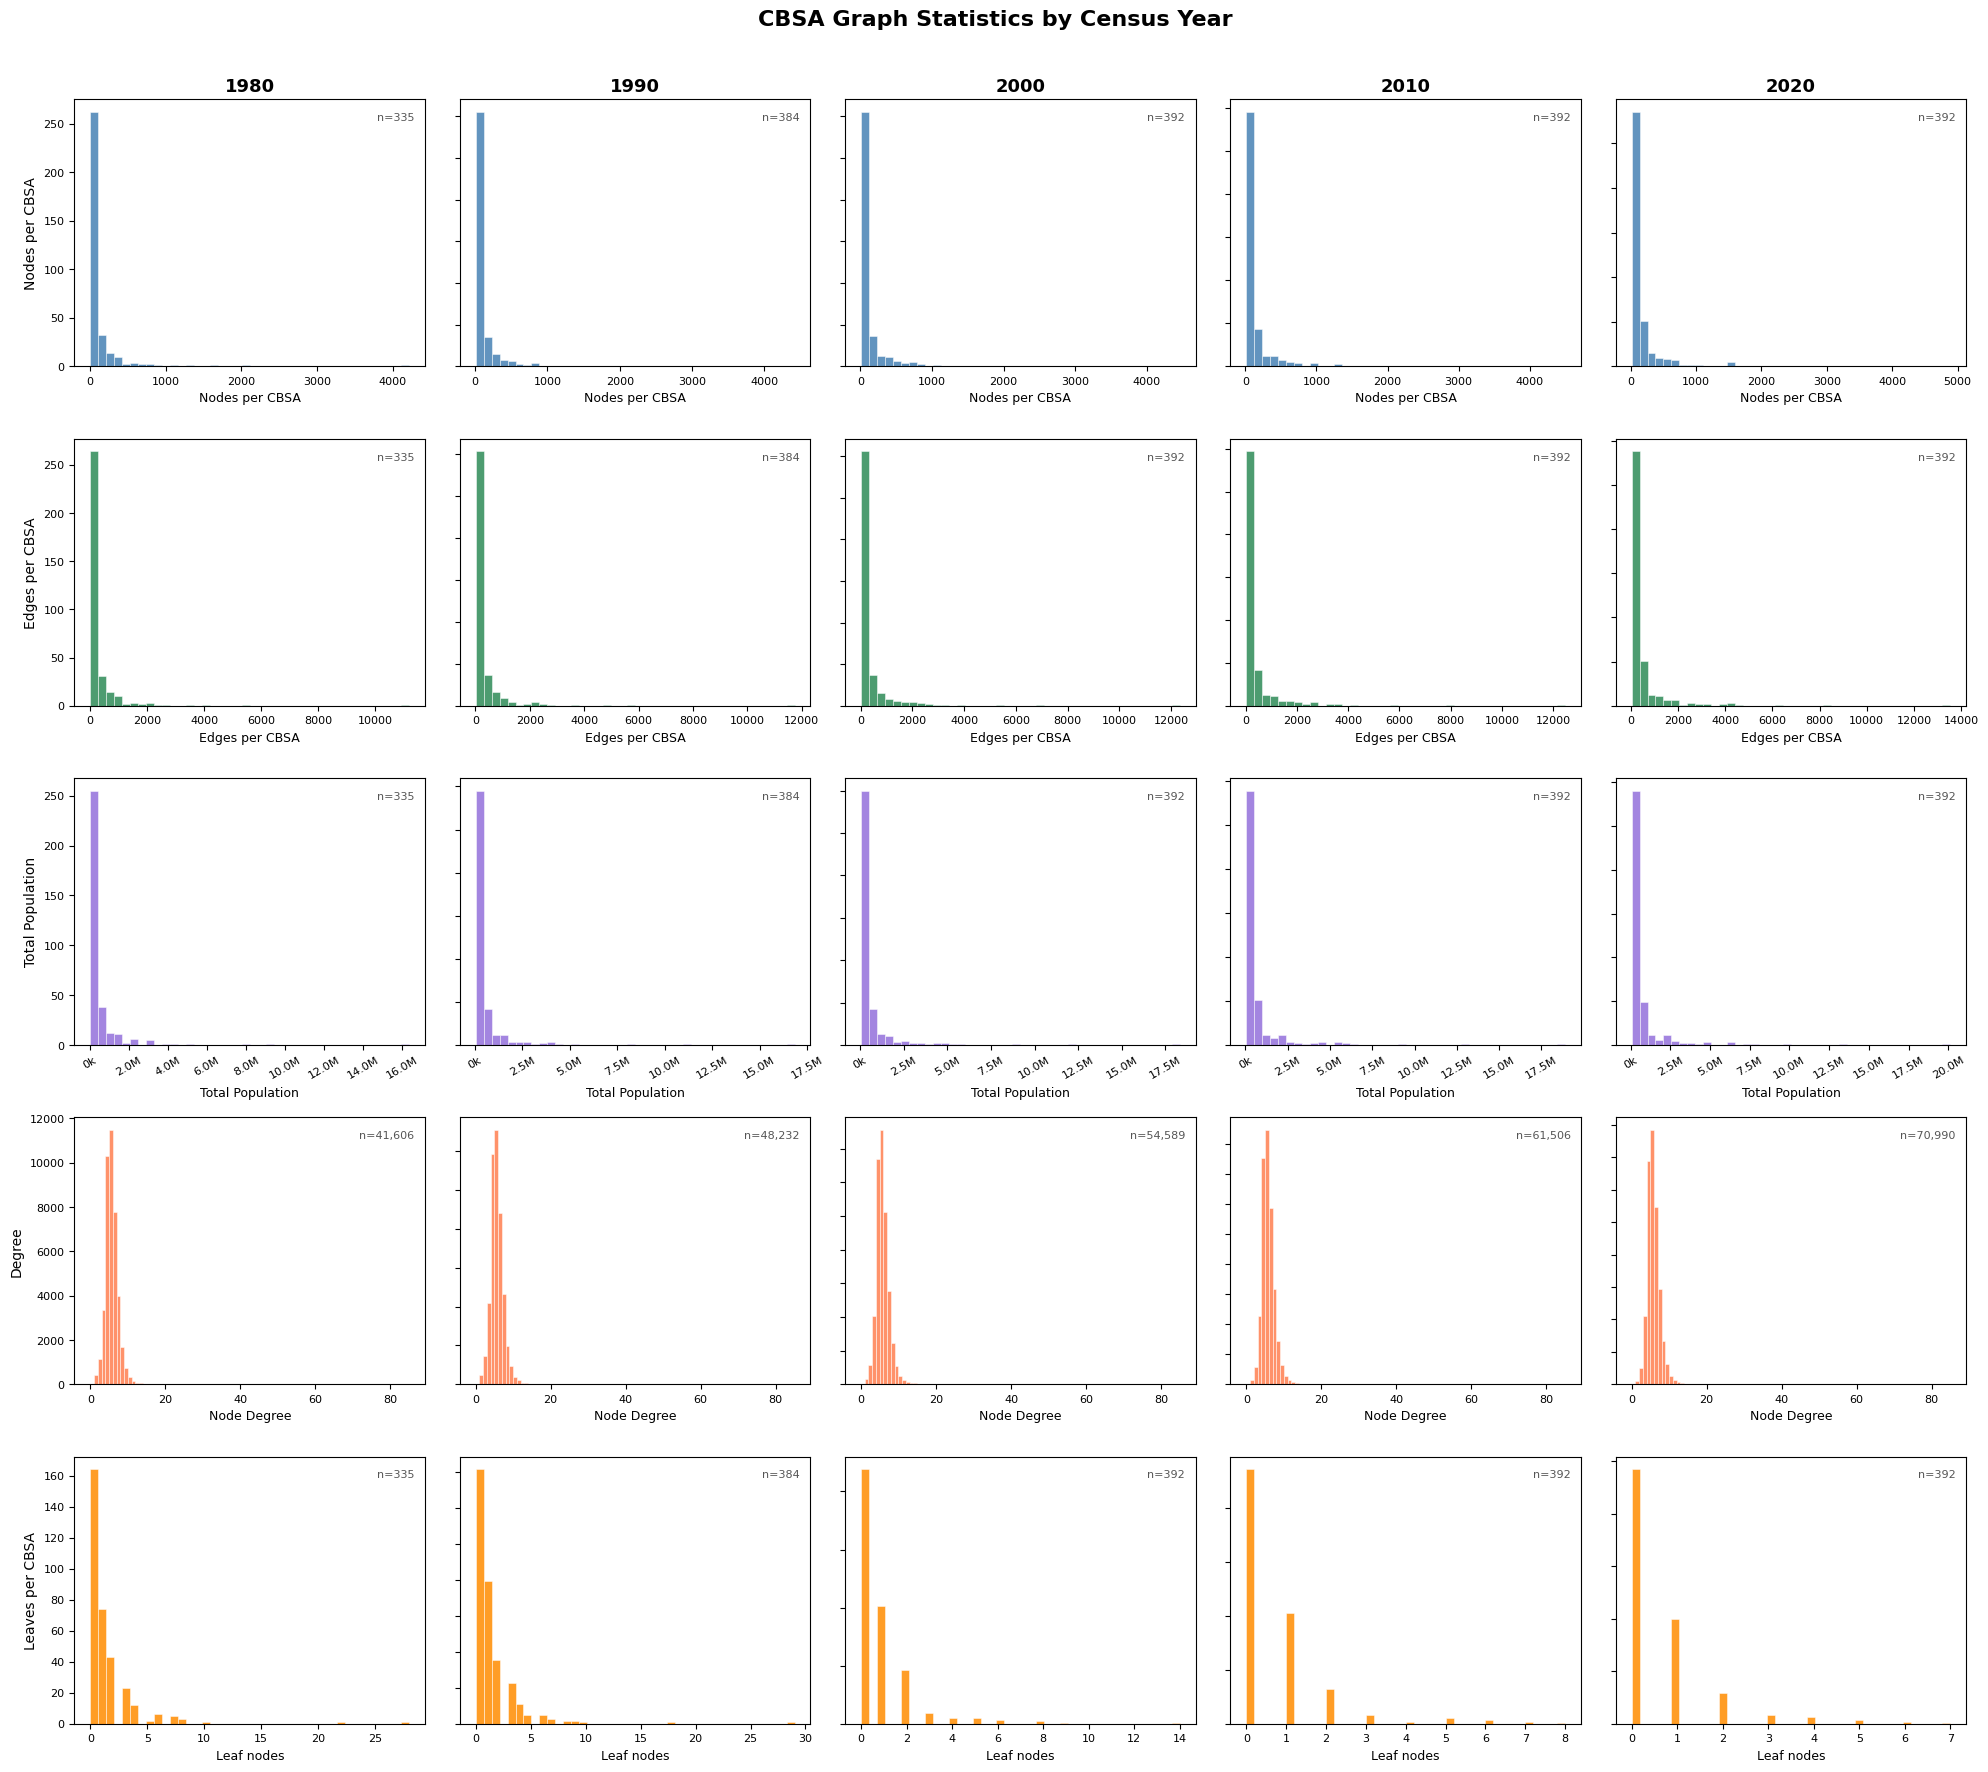

Saved figures/cbsa_histograms_below.png


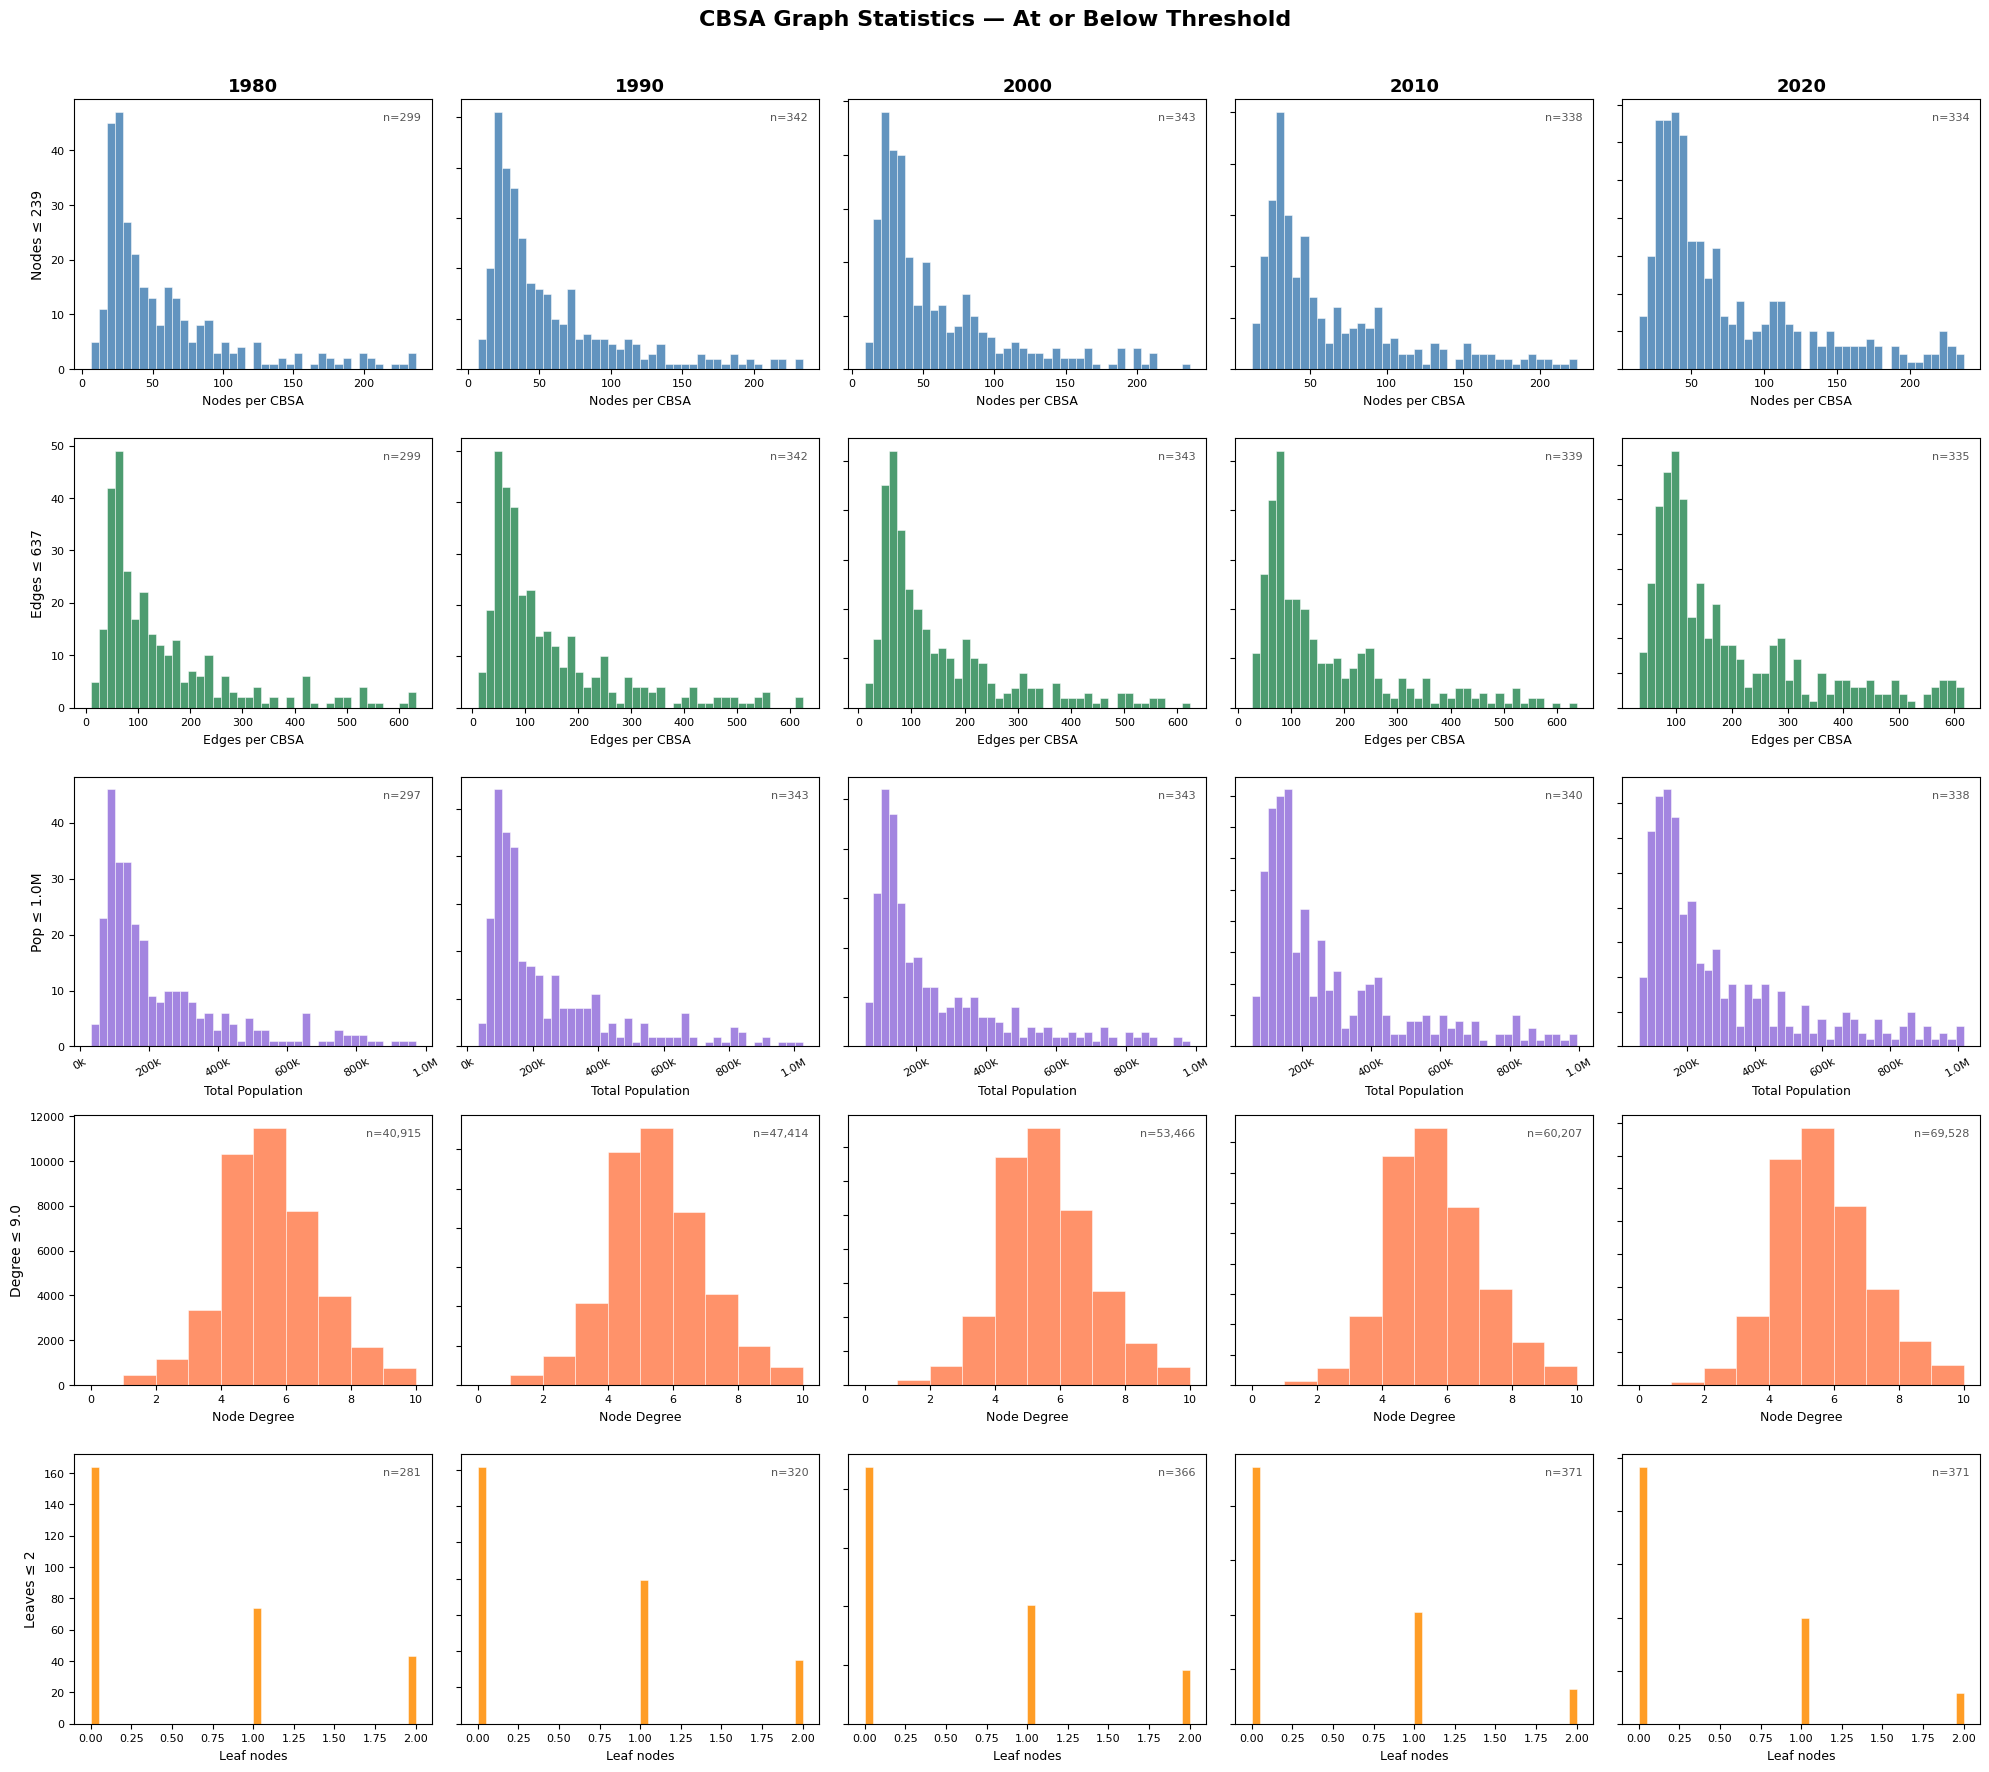

Saved figures/cbsa_histograms_above.png


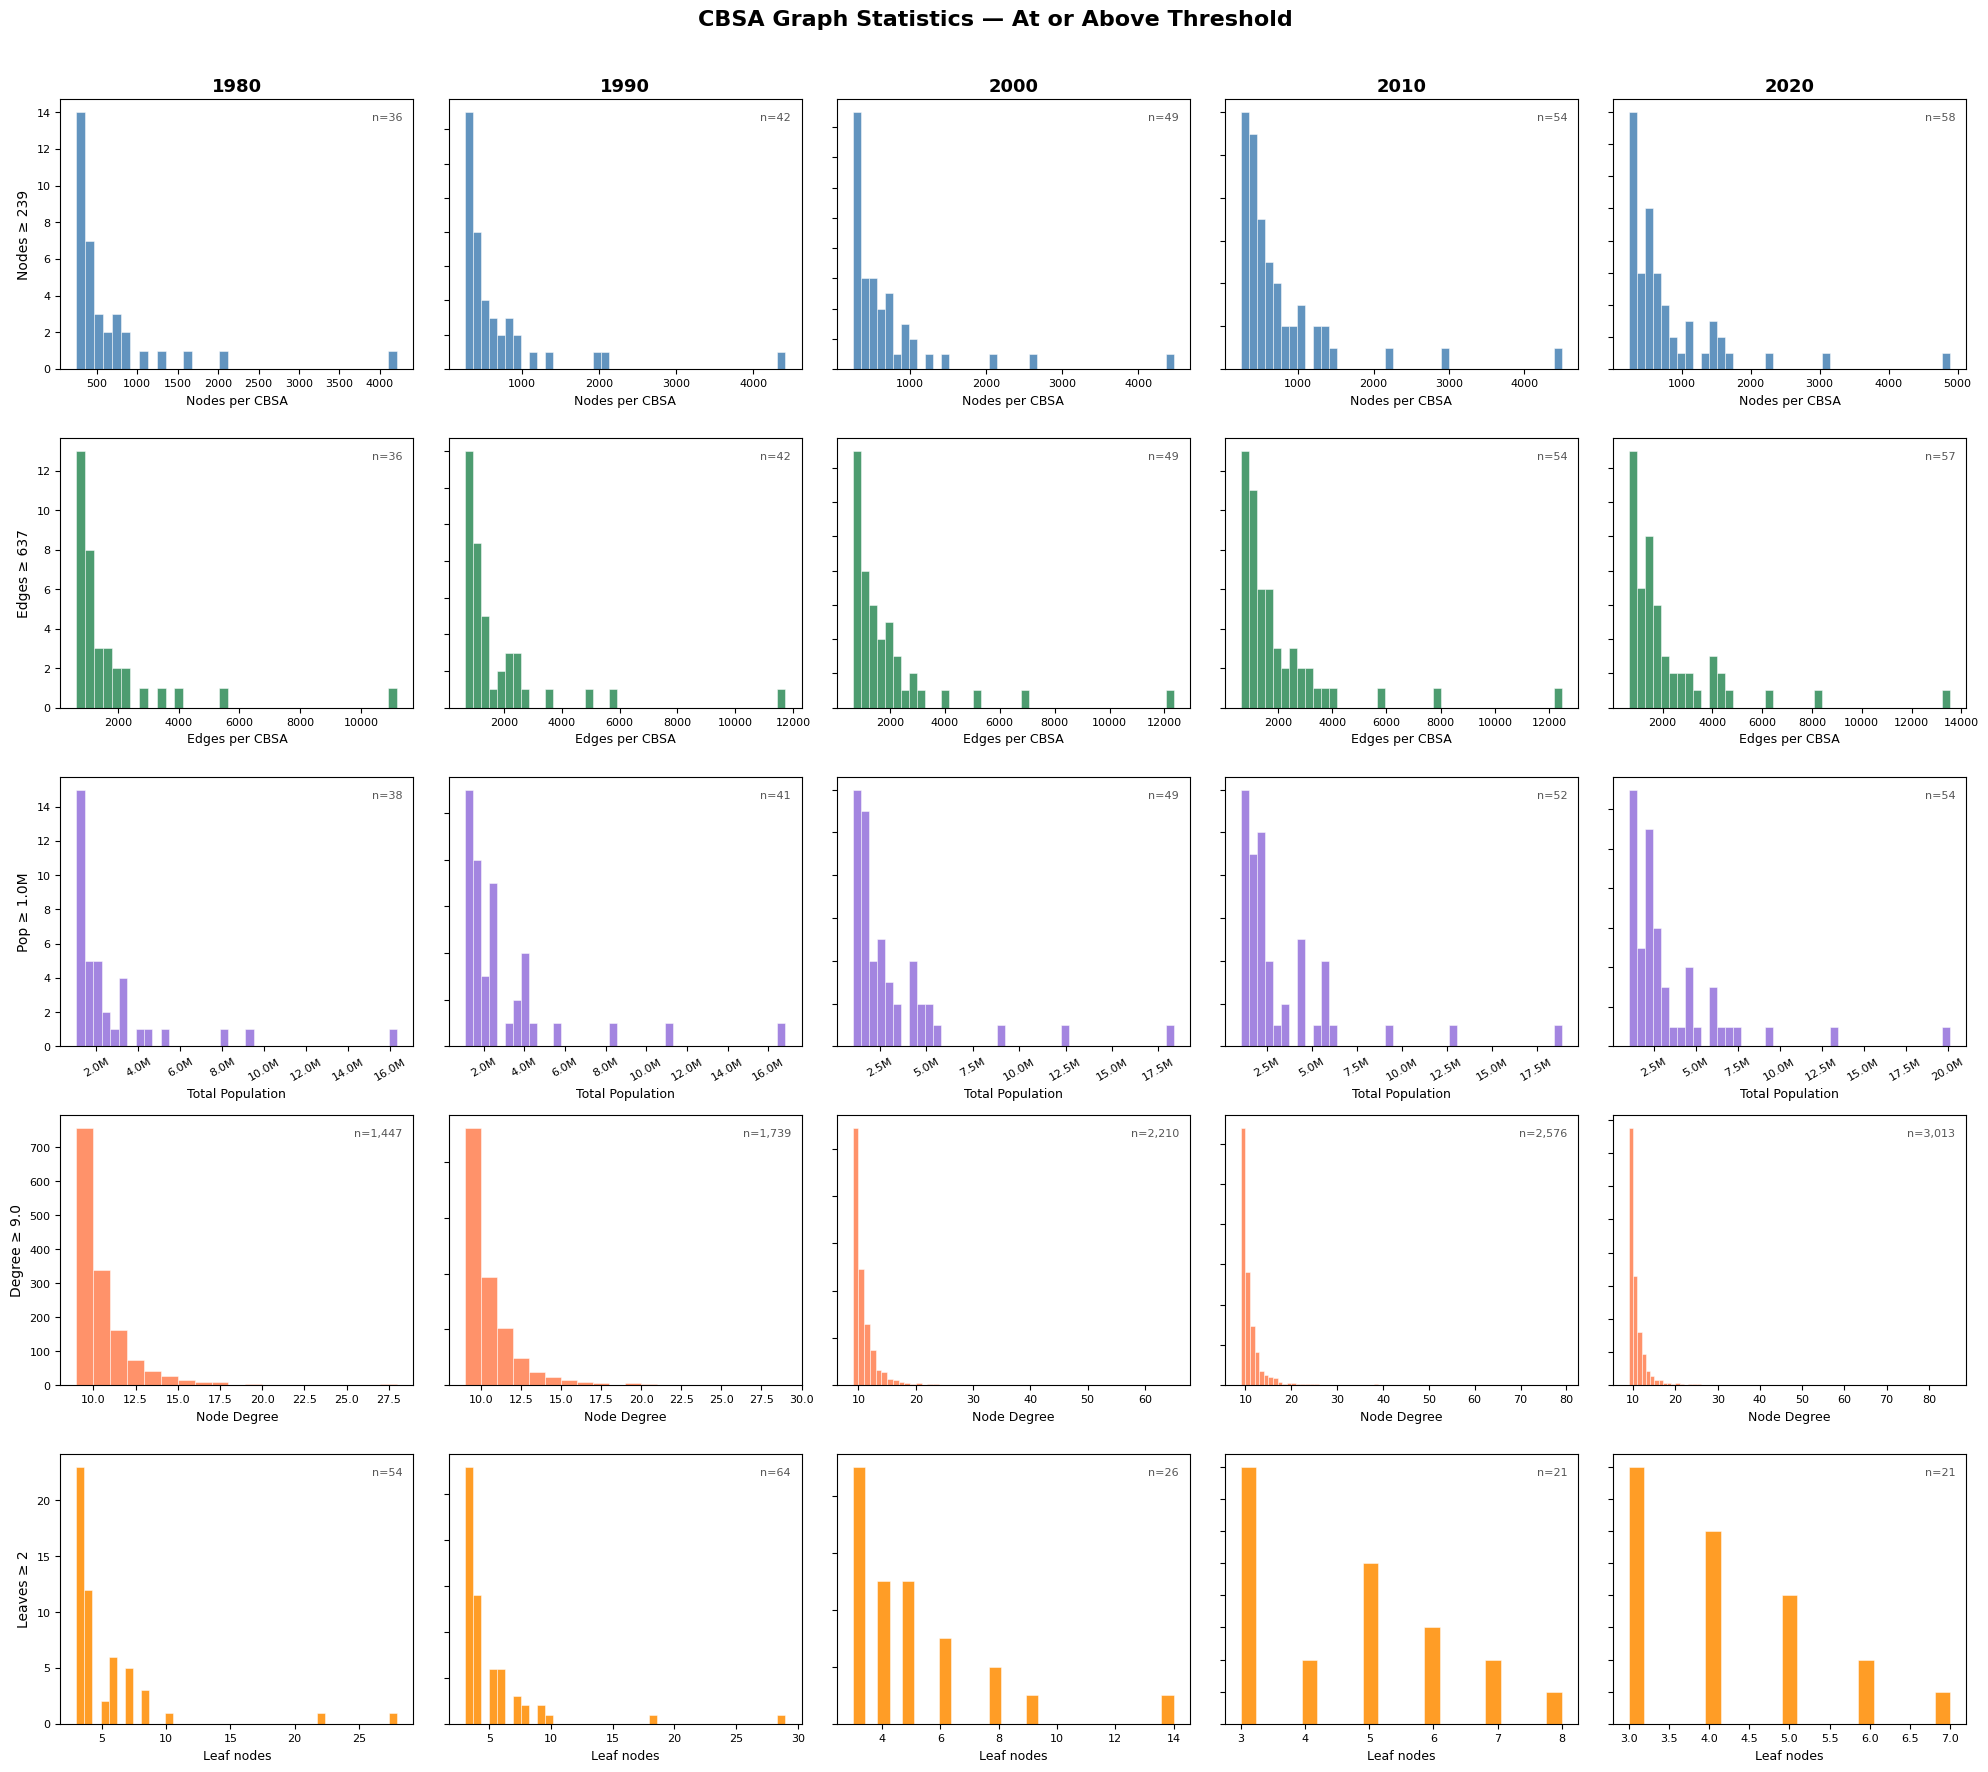

In [5]:
def make_fig(title, row_defs, deg_bins_fn=None):
    """
    Draw an n-row × 5-col histogram grid.
    row_defs: list of (ylabel, xlabel, color, formatter_or_None, get_vals_fn)
    Degree row (index 3) uses deg_bins_fn for integer-aligned bins.
    """
    n_rows = len(row_defs)
    fig, axes = plt.subplots(n_rows, len(YEARS), figsize=(4 * len(YEARS), 3.5 * n_rows))
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)

    for row, (ylabel, xlabel, color, fmt, get_vals) in enumerate(row_defs):
        for col, yr in enumerate(YEARS):
            ax = axes[row][col]
            vals = get_vals(yr)

            if row == 3:
                bins = deg_bins_fn(yr) if deg_bins_fn else range(0, (max(vals) if vals else 1) + 2)
            else:
                bins = min(40, len(vals)) if len(vals) > 1 else 1

            if vals:
                ax.hist(vals, bins=bins, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
            if col == 0:
                ax.set_ylabel(ylabel, fontsize=10)
            else:
                ax.set_yticklabels([])
            if row == 0:
                ax.set_title(str(yr), fontsize=13, fontweight='bold')
            ax.set_xlabel(xlabel, fontsize=9)
            ax.tick_params(labelsize=8)
            if fmt:
                ax.xaxis.set_major_formatter(fmt)
                ax.tick_params(axis='x', rotation=30)
            ax.text(0.97, 0.95, f'n={len(vals):,}', transform=ax.transAxes,
                    ha='right', va='top', fontsize=8, color='#555')

    plt.tight_layout()
    return fig


pop_fmt = mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k')

# ── Figure 1: full distributions ──────────────────────────────────────────────
all_degrees = [d for yr in YEARS for r in data[yr] for d in r['degrees']]
max_deg_all = max(all_degrees) if all_degrees else 1

ROWS_ALL = [
    ('Nodes per CBSA',  'Nodes per CBSA',  'steelblue',   None,    lambda yr: [r['n_nodes']   for r in data[yr]]),
    ('Edges per CBSA',  'Edges per CBSA',  'seagreen',    None,    lambda yr: [r['n_edges']   for r in data[yr]]),
    ('Total Population','Total Population','mediumpurple', pop_fmt, lambda yr: [r['total_pop'] for r in data[yr]]),
    ('Degree',          'Node Degree',     'coral',        None,    lambda yr: [d for r in data[yr] for d in r['degrees']]),
    ('Leaves per CBSA', 'Leaf nodes',      'darkorange',   None,    lambda yr: [r['n_leaves']  for r in data[yr]]),
]

fig1 = make_fig('CBSA Graph Statistics by Census Year', ROWS_ALL,
                deg_bins_fn=lambda yr: range(0, max_deg_all + 2))
os.makedirs('figures', exist_ok=True)
fig1.savefig('figures/cbsa_histograms.png', dpi=150, bbox_inches='tight')
print('Saved figures/cbsa_histograms.png')
plt.show()

# ── Figure 2: at or below threshold ───────────────────────────────────────────
ROWS_LOW = [
    (f'Nodes ≤ {thresh_nodes:,.0f}',   'Nodes per CBSA',  'steelblue',   None,    lambda yr: [r['n_nodes']   for r in data[yr] if r['n_nodes']   <= thresh_nodes]),
    (f'Edges ≤ {thresh_edges:,.0f}',   'Edges per CBSA',  'seagreen',    None,    lambda yr: [r['n_edges']   for r in data[yr] if r['n_edges']   <= thresh_edges]),
    (f'Pop ≤ {thresh_pop/1e6:.1f}M',   'Total Population','mediumpurple', pop_fmt, lambda yr: [r['total_pop'] for r in data[yr] if r['total_pop'] <= thresh_pop]),
    (f'Degree ≤ {thresh_deg:.1f}',     'Node Degree',     'coral',        None,    lambda yr: [d for r in data[yr] for d in r['degrees'] if d <= thresh_deg]),
    (f'Leaves ≤ {thresh_leaves:,.0f}', 'Leaf nodes',      'darkorange',   None,    lambda yr: [r['n_leaves']  for r in data[yr] if r['n_leaves']  <= thresh_leaves]),
]

fig2 = make_fig('CBSA Graph Statistics — At or Below Threshold', ROWS_LOW,
                deg_bins_fn=lambda yr: range(0, int(thresh_deg) + 2))
fig2.savefig('figures/cbsa_histograms_below.png', dpi=150, bbox_inches='tight')
print('Saved figures/cbsa_histograms_below.png')
plt.show()

# ── Figure 3: at or above threshold ───────────────────────────────────────────
ROWS_HIGH = [
    (f'Nodes ≥ {thresh_nodes:,.0f}',   'Nodes per CBSA',  'steelblue',   None,    lambda yr: [r['n_nodes']   for r in data[yr] if r['n_nodes']   >= thresh_nodes]),
    (f'Edges ≥ {thresh_edges:,.0f}',   'Edges per CBSA',  'seagreen',    None,    lambda yr: [r['n_edges']   for r in data[yr] if r['n_edges']   >= thresh_edges]),
    (f'Pop ≥ {thresh_pop/1e6:.1f}M',   'Total Population','mediumpurple', pop_fmt, lambda yr: [r['total_pop'] for r in data[yr] if r['total_pop'] >= thresh_pop]),
    (f'Degree ≥ {thresh_deg:.1f}',     'Node Degree',     'coral',        None,    lambda yr: [d for r in data[yr] for d in r['degrees'] if d >= thresh_deg]),
    (f'Leaves ≥ {thresh_leaves:,.0f}', 'Leaf nodes',      'darkorange',   None,    lambda yr: [r['n_leaves']  for r in data[yr] if r['n_leaves']  >= thresh_leaves]),
]

def deg_bins_high(yr):
    vals = [d for r in data[yr] for d in r['degrees'] if d >= thresh_deg]
    return range(int(thresh_deg), (max(vals) if vals else int(thresh_deg) + 1) + 2)

fig3 = make_fig('CBSA Graph Statistics — At or Above Threshold', ROWS_HIGH,
                deg_bins_fn=deg_bins_high)
fig3.savefig('figures/cbsa_histograms_above.png', dpi=150, bbox_inches='tight')
print('Saved figures/cbsa_histograms_above.png')
plt.show()

In [6]:
# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Year':>6}  {'CBSAs':>6}  {'Med Nodes':>10}  {'Med Edges':>10}  {'Med TotPop':>12}  {'Med Degree':>11}")
print('-' * 64)
for yr in YEARS:
    recs = data[yr]
    nodes  = [r['n_nodes']   for r in recs]
    edges  = [r['n_edges']   for r in recs]
    pops   = [r['total_pop'] for r in recs]
    degs   = [d for r in recs for d in r['degrees']]
    print(f"{yr:>6}  {len(recs):>6}  "
          f"{np.median(nodes):>10.0f}  "
          f"{np.median(edges):>10.0f}  "
          f"{np.median(pops):>12,.0f}  "
          f"{np.median(degs):>11.2f}")

  Year   CBSAs   Med Nodes   Med Edges    Med TotPop   Med Degree
----------------------------------------------------------------
  1980     335          45         112       177,712         5.00
  1990     384          45         110       182,054         5.00
  2000     392          49         118       201,520         5.00
  2010     392          52         134       230,476         5.00
  2020     392          63         161       243,728         5.00


## Split Histograms

Figures 2 and 3 mirror the full layout above but restrict each panel to CBSAs (or nodes, for degree) below or at/above a **Tukey upper-fence threshold** computed from pooled data across all decades:

```
threshold = Q3 + 1.5 × IQR   (where Q1/Q3 are pooled over 1980–2020)
```

Thresholds are printed by the cell above. Observations exactly at the threshold appear in **both** split figures.

In [7]:
# ── Top-20 outliers per year per metric ───────────────────────────────────────
OUTLIER_METRICS = [
    ('n_nodes',   'Nodes',      lambda r: r['n_nodes'],                 '{:>6}'),
    ('n_edges',   'Edges',      lambda r: r['n_edges'],                 '{:>6}'),
    ('total_pop', 'Total Pop',  lambda r: r['total_pop'],               '{:>12,}'),
    ('max_deg',   'Max Degree', lambda r: max(r['degrees'], default=0), '{:>10}'),
    ('n_leaves',  'Leaves',     lambda r: r['n_leaves'],                '{:>6}'),
]

TOP_N = 20

for metric_key, metric_label, key_fn, val_fmt in OUTLIER_METRICS:
    print(f"\n{'='*80}")
    print(f"  Top {TOP_N} by {metric_label}")
    print(f"{'='*80}")
    for yr in YEARS:
        ranked = sorted(data[yr], key=key_fn, reverse=True)[:TOP_N]
        print(f"\n  {yr}")
        print(f"  {'Rank':>4}  {'Code':>6}  {metric_label:>12}  Name")
        print(f"  {'-'*70}")
        for i, r in enumerate(ranked, 1):
            val_str = val_fmt.format(key_fn(r))
            print(f"  {i:>4}  {str(r['cbsa_code']):>6}  {val_str}  {r['cbsa_name']}")


  Top 20 by Nodes

  1980
  Rank    Code         Nodes  Name
  ----------------------------------------------------------------------
     1   35620    4217  New York-Newark-Jersey City, NY-NJ-PA
     2   31080    2049  Los Angeles-Long Beach-Anaheim, CA
     3   16980    1657  Chicago-Naperville-Elgin, IL-IN-WI
     4   37980    1332  Philadelphia-Camden-Wilmington, PA-NJ-DE-MD
     5   19820    1109  Detroit-Warren-Dearborn, MI
     6   14460     849  Boston-Cambridge-Newton, MA-NH
     7   47900     834  Washington-Arlington-Alexandria, DC-VA-MD-WV
     8   41860     787  San Francisco-Oakland-Hayward, CA
     9   38300     718  Pittsburgh, PA
    10   26420     695  Houston-The Woodlands-Sugar Land, TX
    11   19100     646  Dallas-Fort Worth-Arlington, TX
    12   33460     609  Minneapolis-St. Paul-Bloomington, MN-WI
    13   12580     564  Baltimore-Columbia-Towson, MD
    14   17460     564  Cleveland-Elyria, OH
    15   33100     535  Miami-Fort Lauderdale-West Palm Beach, F

In [8]:
# ── Top-20 rank-difference pairs ──────────────────────────────────────────────
# For each pair of metrics, rank all CBSAs in a given year (rank 1 = largest),
# then find the 20 with the biggest absolute difference between the two ranks.

RANK_PAIRS = [
    ('pop',   'nodes', lambda r: r['total_pop'], lambda r: r['n_nodes']),
    ('pop',   'edges', lambda r: r['total_pop'], lambda r: r['n_edges']),
    ('nodes', 'edges', lambda r: r['n_nodes'],   lambda r: r['n_edges']),
]

for label_a, label_b, key_a, key_b in RANK_PAIRS:
    print(f"\n{'='*85}")
    print(f"  Top {TOP_N} absolute rank differences: {label_a} vs {label_b}")
    print(f"{'='*85}")
    for yr in YEARS:
        recs = data[yr]
        rank_a = {r['file']: i + 1 for i, r in enumerate(sorted(recs, key=key_a, reverse=True))}
        rank_b = {r['file']: i + 1 for i, r in enumerate(sorted(recs, key=key_b, reverse=True))}

        scored = sorted(recs,
                        key=lambda r: abs(rank_a[r['file']] - rank_b[r['file']]),
                        reverse=True)[:TOP_N]

        print(f"\n  {yr}  (n={len(recs)} CBSAs)")
        print(f"  {'#':>3}  {'Code':>6}  {'Rk('+label_a+')':>10}  {'Rk('+label_b+')':>10}  {'|Diff|':>8}  Name")
        print(f"  {'-'*75}")
        for i, r in enumerate(scored, 1):
            ra   = rank_a[r['file']]
            rb   = rank_b[r['file']]
            diff = abs(ra - rb)
            print(f"  {i:>3}  {str(r['cbsa_code']):>6}  {ra:>10}  {rb:>10}  {diff:>8}  {r['cbsa_name']}")


  Top 20 absolute rank differences: pop vs nodes

  1980  (n=335 CBSAs)
    #    Code     Rk(pop)   Rk(nodes)    |Diff|  Name
  ---------------------------------------------------------------------------
    1   29180         196         288        92  Lafayette, LA
    2   22220         166         255        89  Fayetteville-Springdale-Rogers, AR-MO
    3   12620         212         147        65  Bangor, ME
    4   23540         193         257        64  Gainesville, FL
    5   39380         229         166        63  Pueblo, CO
    6   30620         249         190        59  Lima, OH
    7   20100         274         217        57  Dover, DE
    8   24020         254         197        57  Glens Falls, NY
    9   32900         216         273        57  Merced, CA
   10   32580         120         175        55  McAllen-Edinburg-Mission, TX
   11   13220         199         253        54  Beckley, WV
   12   46220         210         264        54  Tuscaloosa, AL
   13   41140  

Saved figures/rank_scatterplots.png


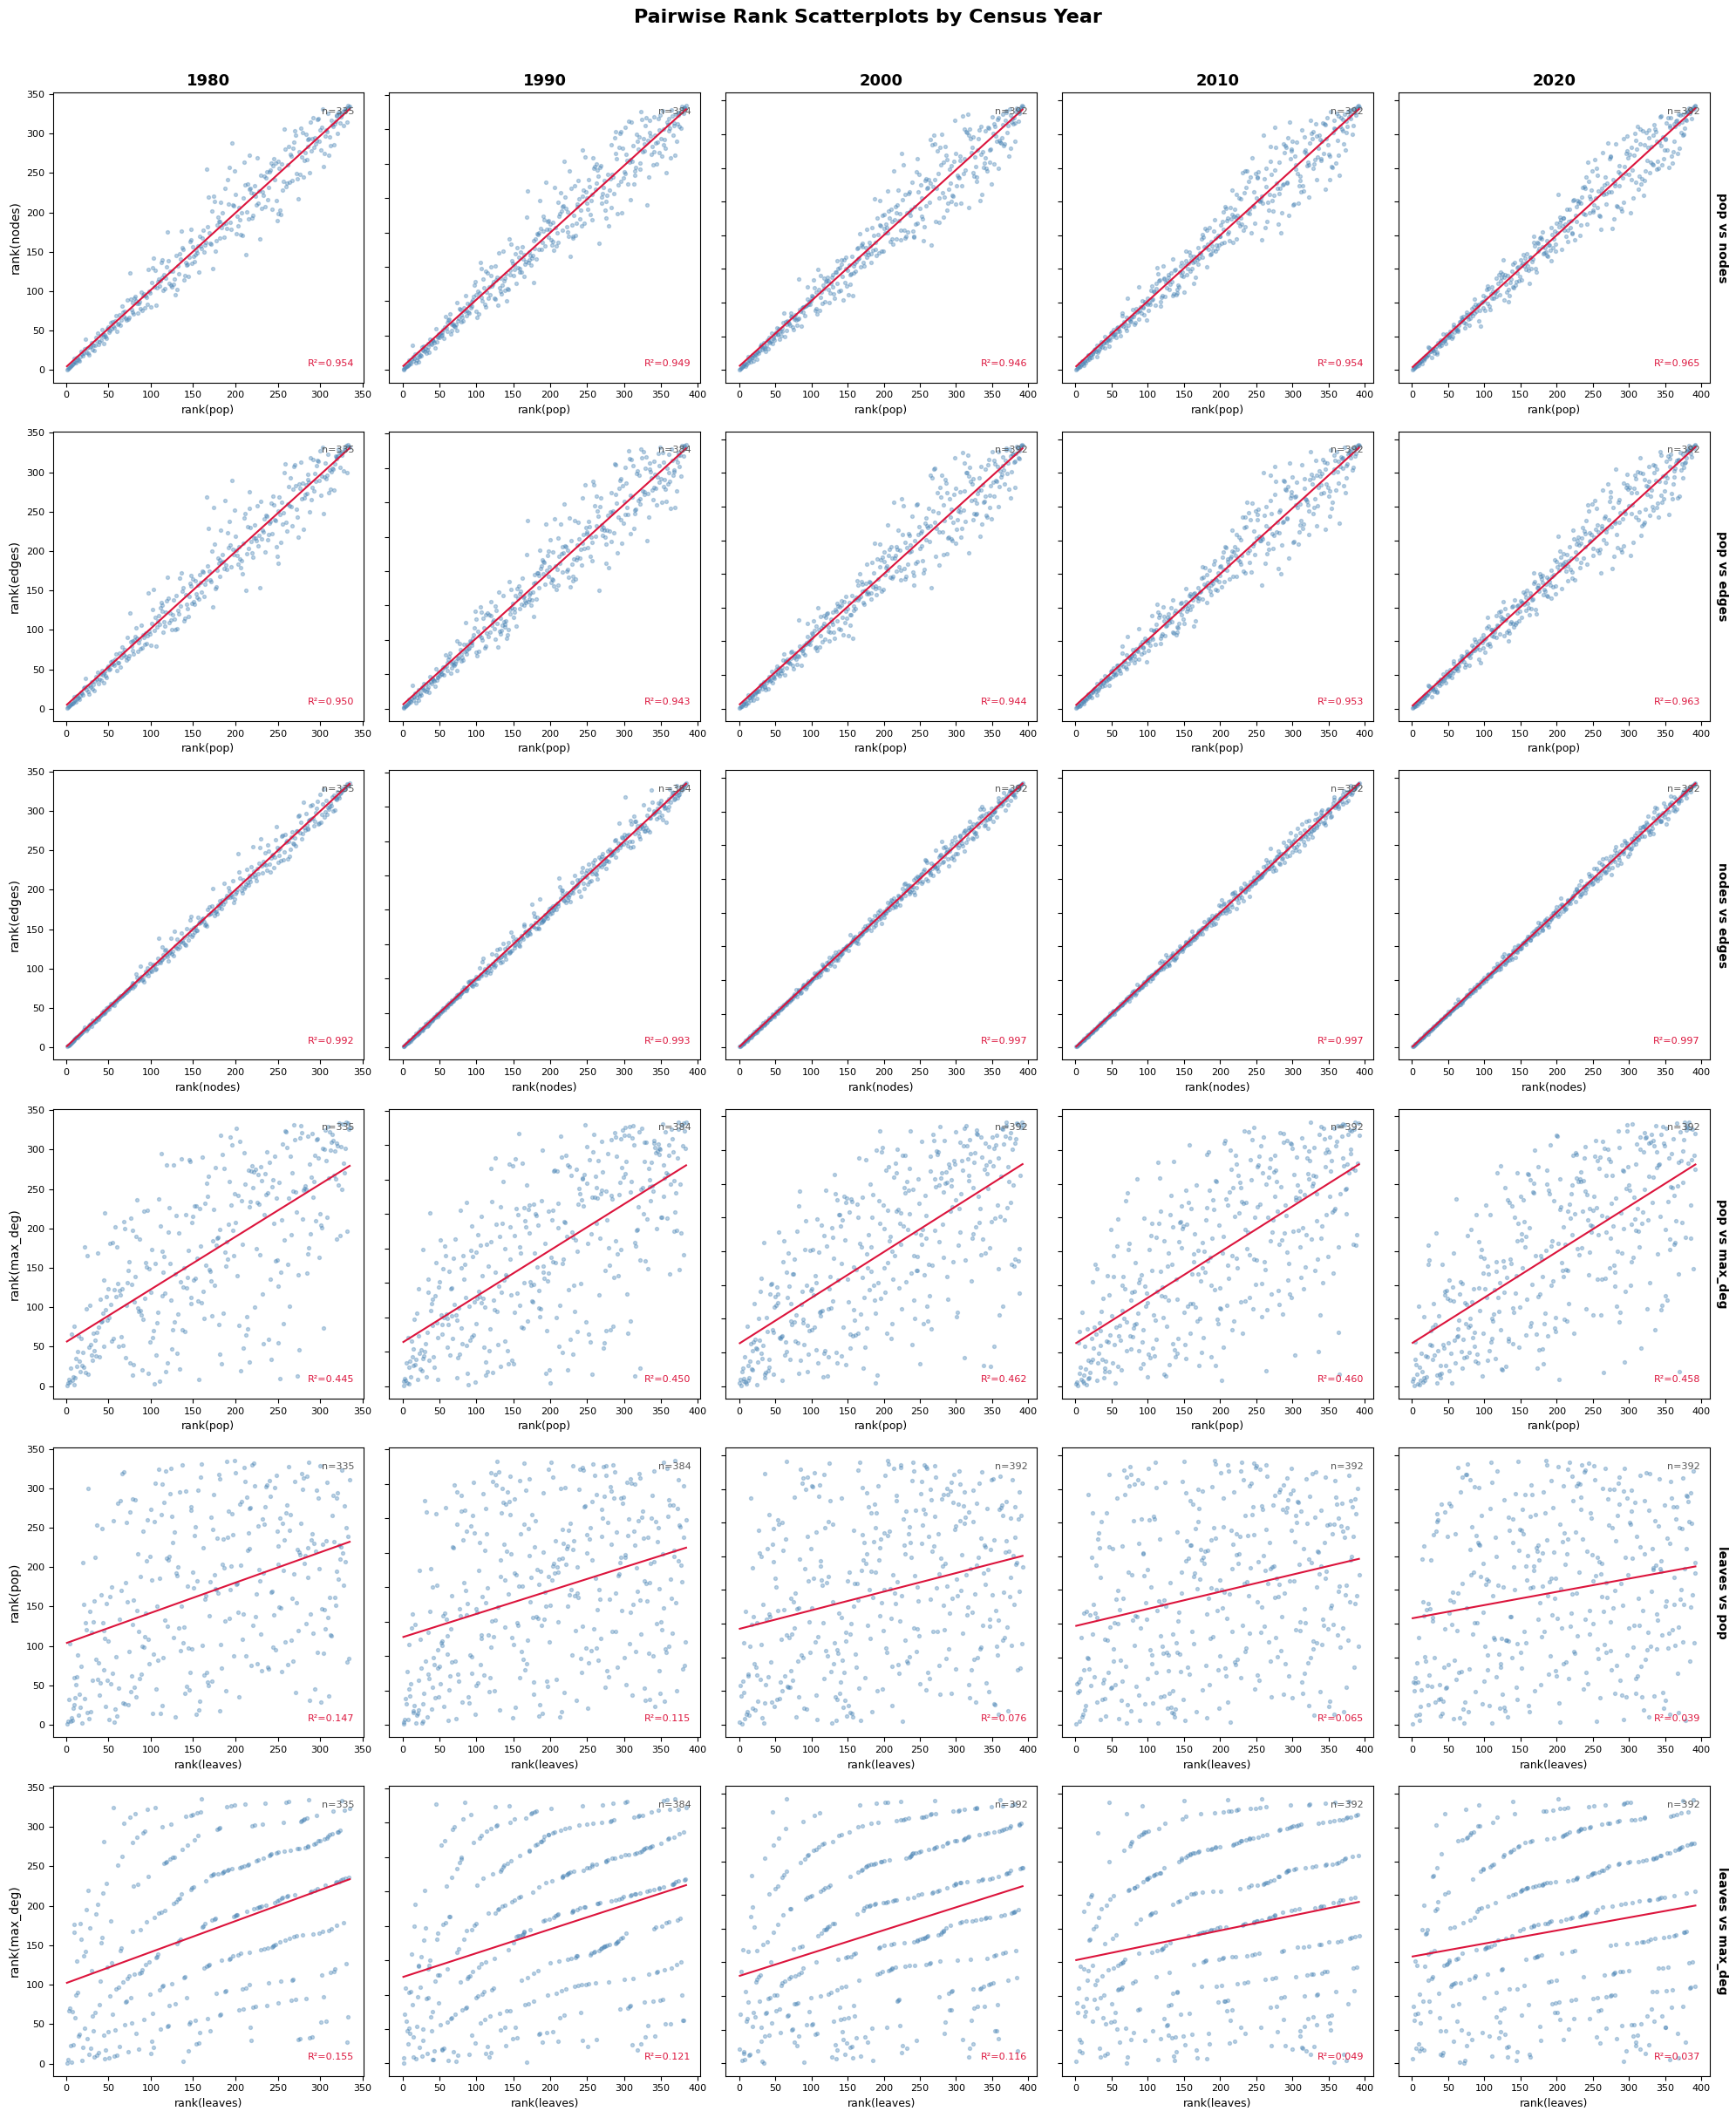

In [9]:
# ── Rank scatterplots with best-fit lines ─────────────────────────────────────
SCATTER_PAIRS = RANK_PAIRS + [
    ('pop',    'max_deg', lambda r: r['total_pop'], lambda r: max(r['degrees'], default=0)),
    ('leaves', 'pop',     lambda r: r['n_leaves'],  lambda r: r['total_pop']),
    ('leaves', 'max_deg', lambda r: r['n_leaves'],  lambda r: max(r['degrees'], default=0)),
]

fig, axes = plt.subplots(len(SCATTER_PAIRS), len(YEARS),
                         figsize=(4 * len(YEARS), 4 * len(SCATTER_PAIRS)))
fig.suptitle('Pairwise Rank Scatterplots by Census Year', fontsize=16, fontweight='bold', y=1.01)

for row, (label_a, label_b, key_a, key_b) in enumerate(SCATTER_PAIRS):
    for col, yr in enumerate(YEARS):
        ax = axes[row][col]
        recs = data[yr]
        rank_a = {r['file']: i + 1 for i, r in enumerate(sorted(recs, key=key_a, reverse=True))}
        rank_b = {r['file']: i + 1 for i, r in enumerate(sorted(recs, key=key_b, reverse=True))}

        x = [rank_a[r['file']] for r in recs]
        y = [rank_b[r['file']] for r in recs]

        ax.scatter(x, y, alpha=0.35, s=8, color='steelblue')

        m, b = np.polyfit(x, y, 1)
        x_range = [min(x), max(x)]
        ax.plot(x_range, [m * xi + b for xi in x_range], color='crimson', linewidth=1.5)

        r2 = np.corrcoef(x, y)[0, 1] ** 2
        ax.text(0.97, 0.95, f'n={len(x):,}', transform=ax.transAxes,
                ha='right', va='top', fontsize=8, color='#555')
        ax.text(0.97, 0.05, f'R²={r2:.3f}', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=8, color='crimson')

        if row == 0:
            ax.set_title(str(yr), fontsize=13, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'rank({label_b})', fontsize=10)
        else:
            ax.set_yticklabels([])
        ax.set_xlabel(f'rank({label_a})', fontsize=9)
        ax.tick_params(labelsize=8)

    axes[row, -1].annotate(f'{label_a} vs {label_b}',
                           xy=(1.02, 0.5), xycoords='axes fraction',
                           fontsize=10, fontweight='bold', va='center', rotation=270)

plt.tight_layout()
fig.savefig('figures/rank_scatterplots.png', dpi=150, bbox_inches='tight')
print('Saved figures/rank_scatterplots.png')
plt.show()